In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Continuous Control Problems

In [2]:
max_gens_dict = {
    "inverted_pendulum": 10,
    "inverted_double_pendulum": 1000,
    "reacher": 1000,
    "swimmer": 1000,
    "hopper": 1500,
    "walker2d": 1500,
    "halfcheetah": 500,
    "miniant": 2500
}

In [3]:
dfs = []
for solver in ["lgp", "cgp"]:
    for seed in range(5):
        for env in ["inverted_double_pendulum", "reacher", "swimmer", "hopper", "walker2d", "halfcheetah", "miniant"]:
            try:
                tmp_df = pd.read_csv(f"../results/gomea_{solver}_{env}_{seed}.csv")
                tmp_df["environment"] = env
                tmp_df["seed"] = seed
                tmp_df["solver"] = solver
                tmp_df["ea"] = "GOMEA"
                dfs.append(tmp_df)
            except FileNotFoundError:
                pass
            try:
                tmp_df = pd.read_csv(f"data/fitness/ga_{solver}_{env}_10{seed}.csv")[
                    ["generation", "reward", "environment", "seed", "solver"]]
                tmp_df["ea"] = "GA"
                tmp_df["fitness"] = tmp_df["reward"]
                tmp_df["iteration"] = tmp_df["generation"]
                dfs.append(tmp_df[tmp_df["generation"] <= max_gens_dict[env]])
            except FileNotFoundError:
                pass

control_df = pd.concat(dfs)
control_df.head()

,iteration,fitness,time,environment,seed,solver,ea,generation,reward
0,0,330.688782,8.85,inverted_double_pendulum,0,lgp,GOMEA,NaN,NaN
1,0,586.532471,1.05,inverted_double_pendulum,0,lgp,GOMEA,NaN,NaN
2,1,623.855896,1.05,inverted_double_pendulum,0,lgp,GOMEA,NaN,NaN
3,2,623.855896,1.05,inverted_double_pendulum,0,lgp,GOMEA,NaN,NaN
4,3,757.745117,1.05,inverted_double_pendulum,0,lgp,GOMEA,NaN,NaN


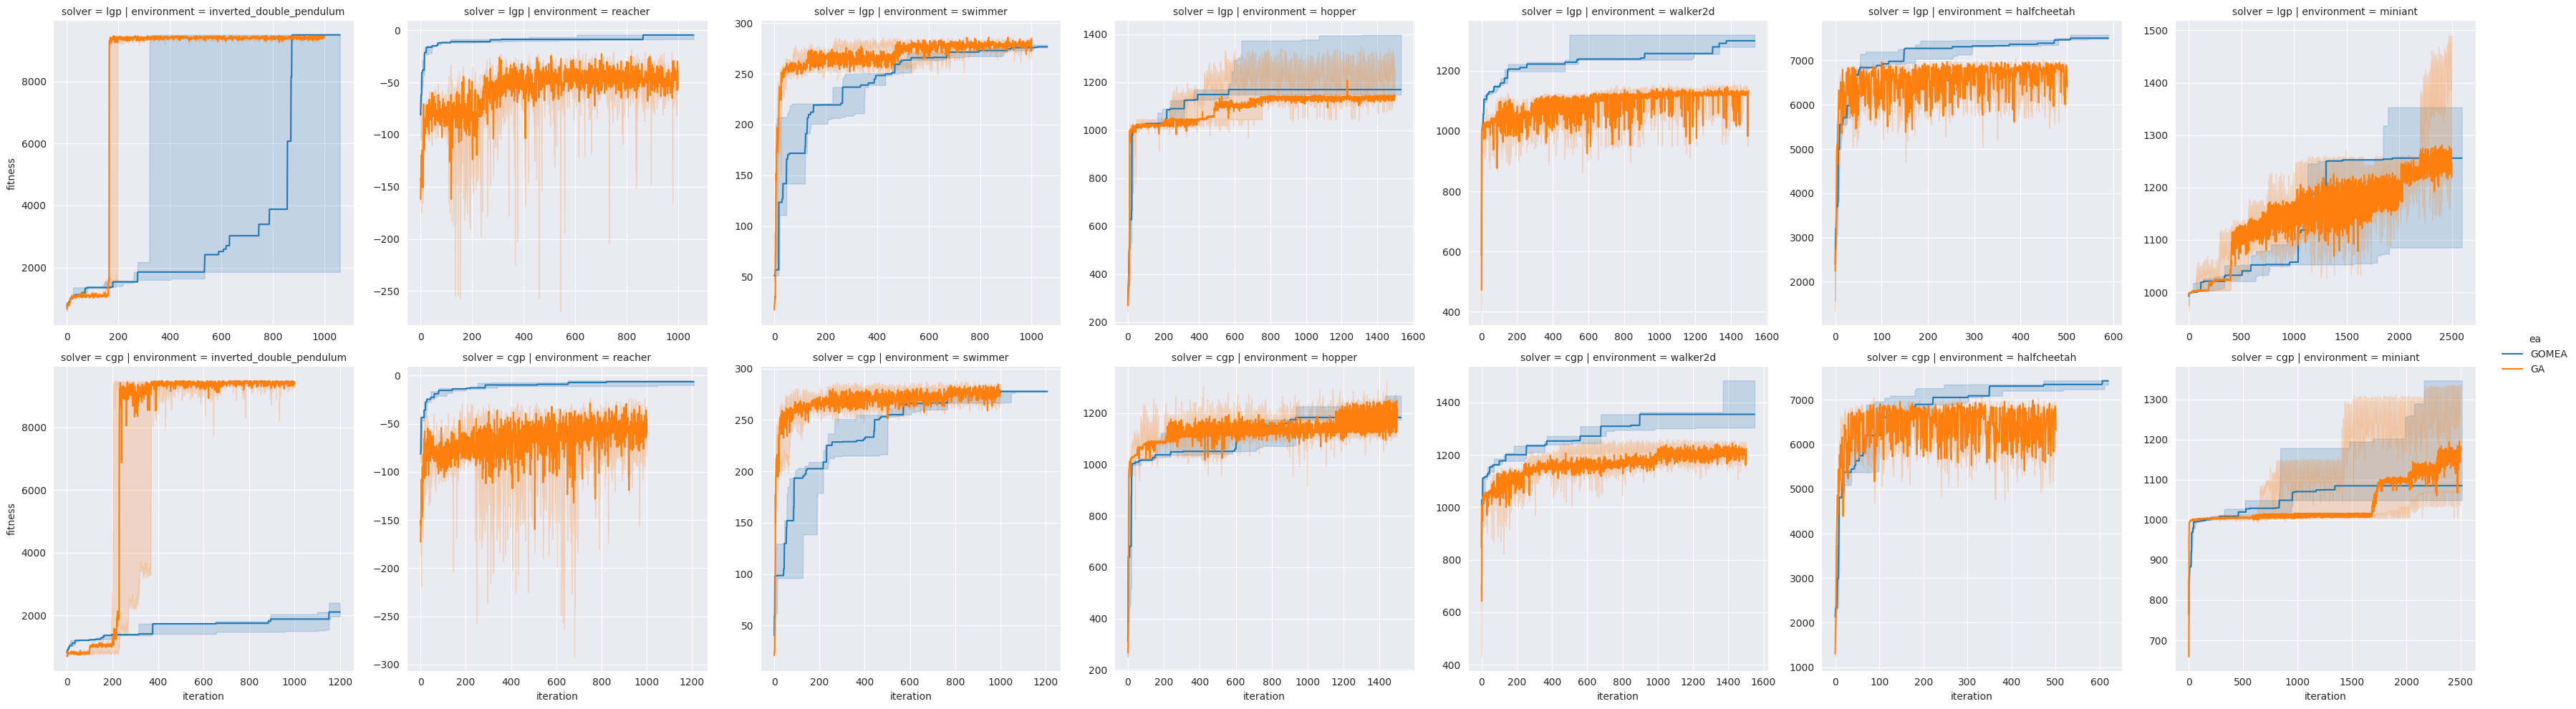

In [4]:
g = sns.relplot(
    data=control_df,
    x="iteration",
    y="fitness",
    # style="ea",
    hue="ea",
    col="environment",
    row="solver",
    # col_wrap=4,
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()

# Boolean Problems

In [19]:
it_max = 4999
boolean_dfs = []
for ea in ["ga", "gomea"]:
    for seed in range(5):
        for solver in ["lgp", "cgp"]:
            for problem in ["adder", "multiplier"]:
                bool_df = pd.read_csv(f"../results/{ea}_{solver}_two_bit_{problem}_{seed}.csv")
                bool_df["seed"] = seed
                bool_df["ea"] = ea
                bool_df["solver"] = solver
                bool_df["problem"] = problem
                boolean_dfs.append(bool_df)
                curr_max_it = int(max(bool_df["iteration"]))
                if curr_max_it < it_max:
                    last_row = bool_df.iloc[-1].copy()
                    for i in range(curr_max_it + 1, it_max + 1):
                        new_row = last_row.copy()
                        new_row["iteration"] = i
                        boolean_dfs.append(pd.DataFrame([new_row]))
boolean_df = pd.concat(boolean_dfs, ignore_index=True)
boolean_df.head()

,iteration,fitness,time,seed,ea,solver,problem
0,0,0.750000,0.24,0,ga,lgp,adder
1,1,0.750000,0.15,0,ga,lgp,adder
2,2,0.791667,0.16,0,ga,lgp,adder
3,3,0.791667,0.15,0,ga,lgp,adder
4,4,0.791667,0.15,0,ga,lgp,adder


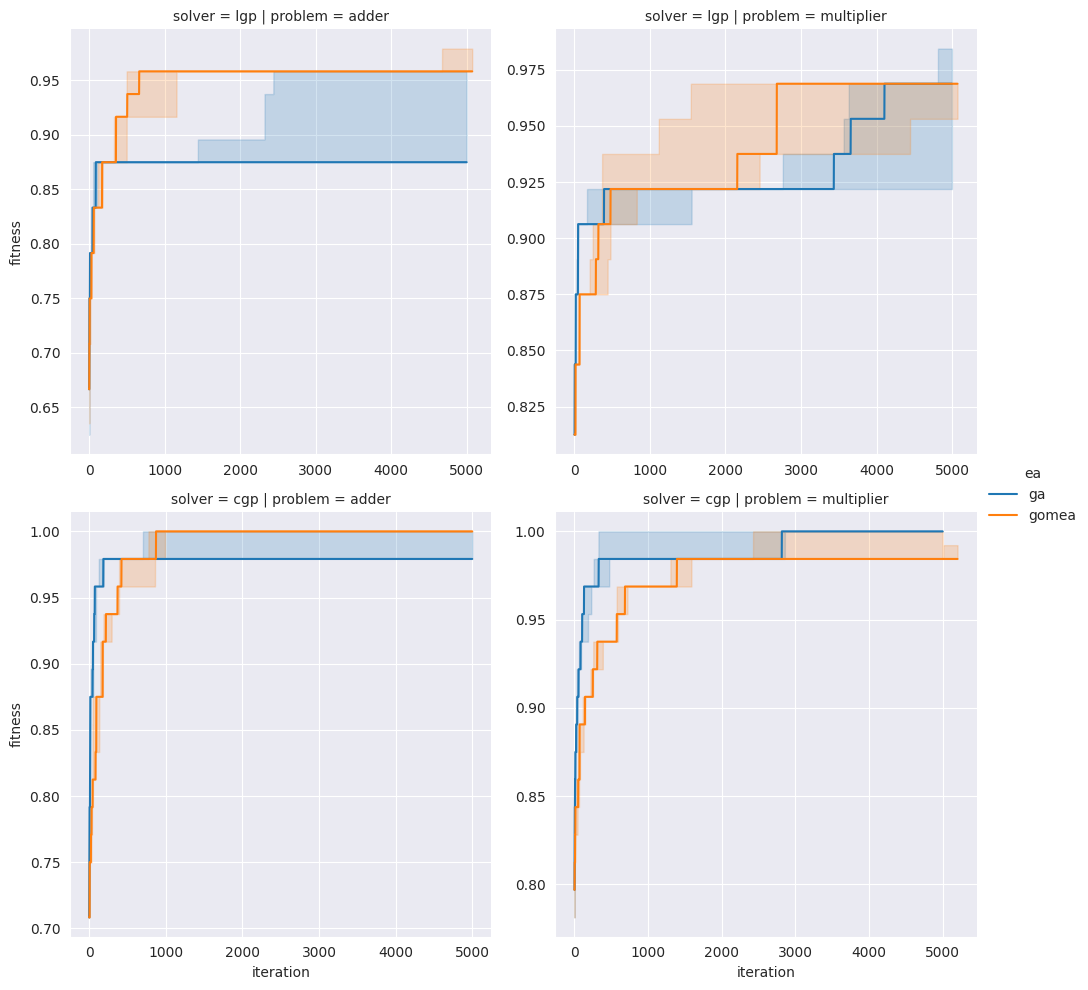

In [20]:
g = sns.relplot(
    data=boolean_df,
    x="iteration",
    y="fitness",
    # style="ea",
    hue="ea",
    col="problem",
    row="solver",
    # col_wrap=4,
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()

# Discrete Control Problems

In [11]:
import os

discrete_envs = ["Acrobot-v1", "CartPole-v1", "LunarLander-v2", "MountainCar-v0"]
discrete_dfs = []
for env in discrete_envs:
    for seed in range(100, 105):
        for solver in ["lgp", "cgp"]:
            for ea in ["ga", "gomea"]:
                processed_env_name = env.lower().split("-")[0]
                df = pd.read_csv(f"../results/{ea}_{solver}_{processed_env_name}_{seed}.csv")
                df["seed"] = seed
                df["ea"] = ea
                df["solver"] = solver
                df["problem"] = processed_env_name
                discrete_dfs.append(df)
discrete_df = pd.concat(discrete_dfs, ignore_index=True)
discrete_df.head()

,iteration,fitness,time,seed,ea,solver,problem
0,0,-70.599998,1.57,100,ga,lgp,acrobot
1,1,-98.000000,1.58,100,ga,lgp,acrobot
2,2,-69.000000,1.52,100,ga,lgp,acrobot
3,3,-69.400002,1.60,100,ga,lgp,acrobot
4,4,-69.599998,1.59,100,ga,lgp,acrobot


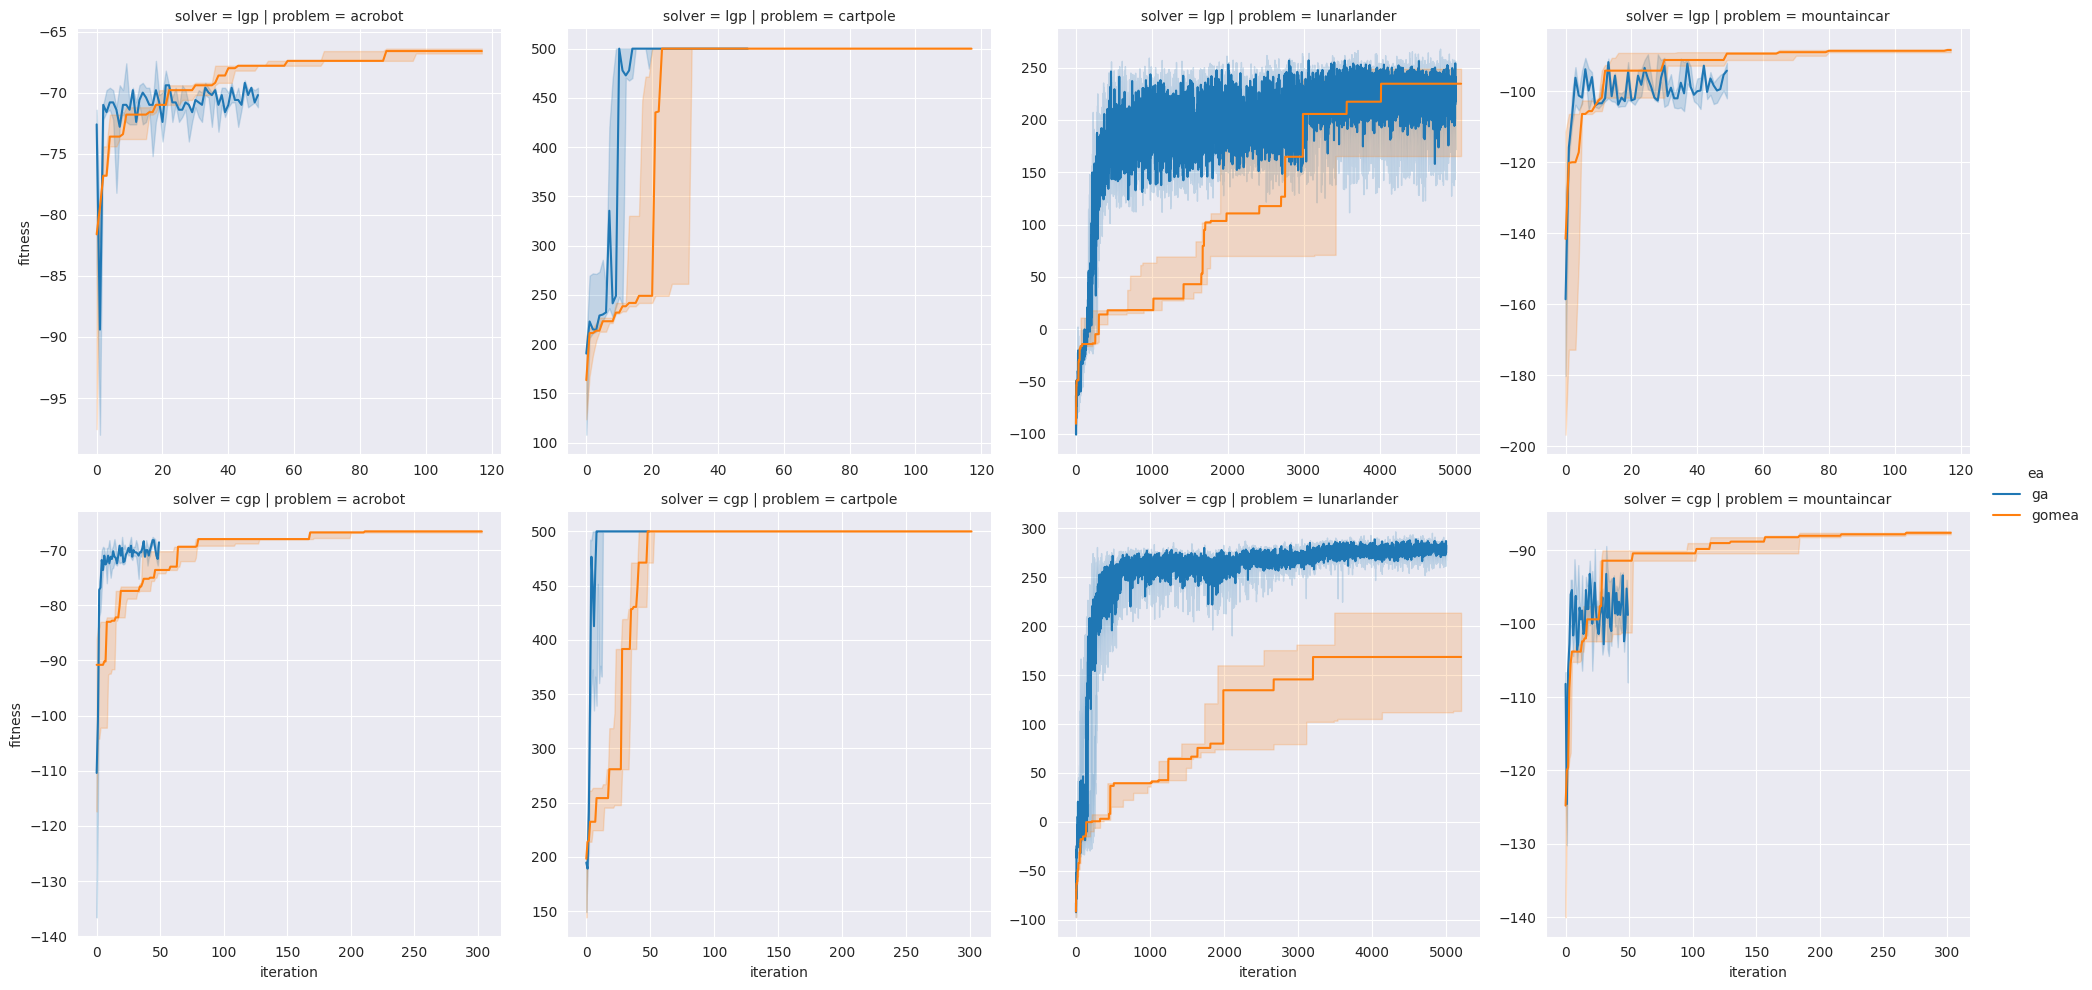

In [12]:
g = sns.relplot(
    data=discrete_df,
    x="iteration",
    y="fitness",
    # style="ea",
    hue="ea",
    col="problem",
    row="solver",
    # col_wrap=4,
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()

# Classification Problems

In [14]:
classification_tasks = ["breast_cancer"]
classification_dfs = []
for ds in classification_tasks:
    for seed in range(5):
        for solver in ["lgp", "cgp"]:
            for ea in ["ga", "gomea"]:
                if ea == "ga":
                    df = pd.read_csv(f"../results/{ea}_{solver}_{ds}_{seed}.csv")
                else:
                    df = pd.read_csv(f"../results/{ea}_{solver}_{ds}_{seed}.csv")
                df["seed"] = seed
                df["ea"] = ea
                df["solver"] = solver
                df["problem"] = ds
                classification_dfs.append(df)
classification_df = pd.concat(classification_dfs, ignore_index=True)
classification_df.head()

,iteration,fitness,test_accuracy,time,seed,ea,solver,problem
0,0,0.876923,0.877193,0.36,0,ga,lgp,breast_cancer
1,1,0.920879,0.894737,0.28,0,ga,lgp,breast_cancer
2,2,0.920879,0.894737,0.36,0,ga,lgp,breast_cancer
3,3,0.920879,0.894737,0.62,0,ga,lgp,breast_cancer
4,4,0.920879,0.894737,0.61,0,ga,lgp,breast_cancer


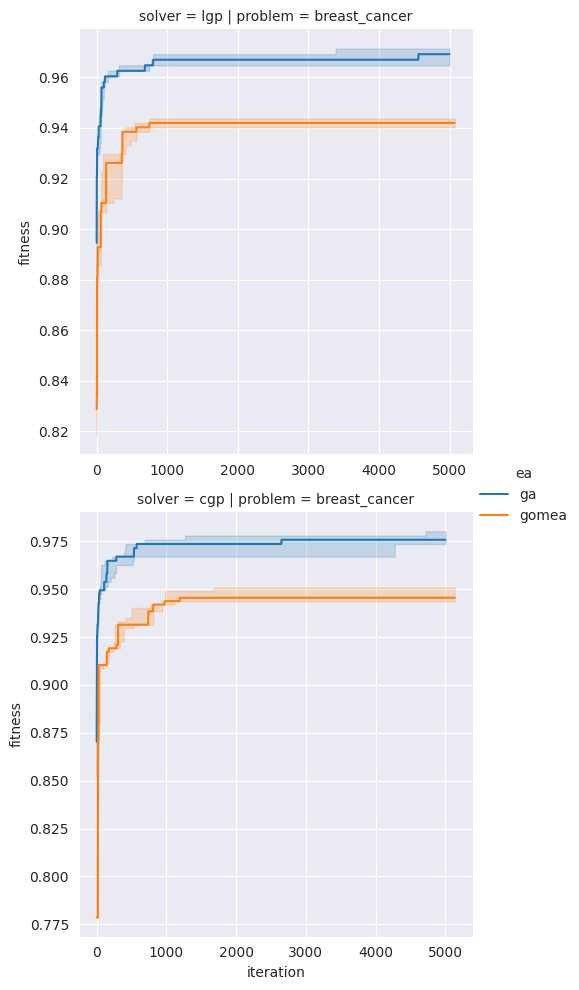

In [15]:
g = sns.relplot(
    data=classification_df,
    x="iteration",
    y="fitness",
    # style="ea",
    hue="ea",
    col="problem",
    row="solver",
    # col_wrap=4,
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()

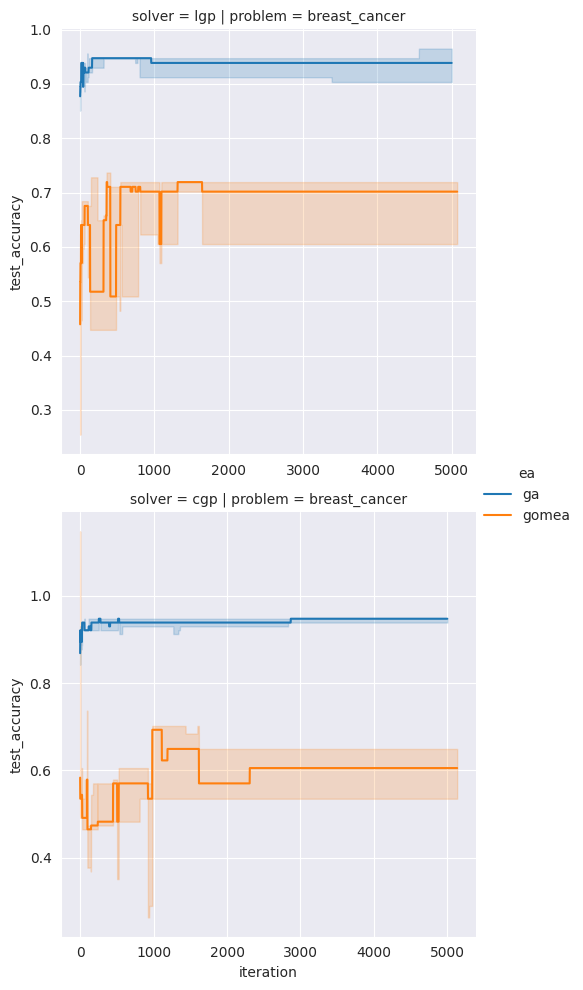

In [16]:
g = sns.relplot(
    data=classification_df,
    x="iteration",
    y="test_accuracy",
    # style="ea",
    hue="ea",
    col="problem",
    row="solver",
    # col_wrap=4,
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    facet_kws=dict(sharey=False, sharex=False)
)
plt.show()